In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [93]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [94]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']
data['MN_FE'] = data['MN_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"
data_all = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#Cuts on r and z
#data_all = data_all[(data_all['galz'] < 2) & (data_all['galz'] > -2) & (data_all['galr'] < 15)]
data_all = data_all[(data_all['galr'] < 15) & (data_all['galr'] > 3) & (data_all['galz'] < 2) & (data_all['galz'] > -2)]
data_all = data_all[data_all['zmax'] < 5]

# Compute binned medians for data
mnmg_high = compute_binned_median(data_all[data_all['high_low_alpha'] == 'high'], x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_all[data_all['high_low_alpha'] == 'low'], x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_all[data_all['high_low_alpha'] == 'high'], x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_all[data_all['high_low_alpha'] == 'low'], x_col='MG_H', y_col='FE_MG', n_bins=20)

# Only keep bins where there is more than 100 stars
mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]

print(len(data_all))

259414


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_48297/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_48297/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_48297/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

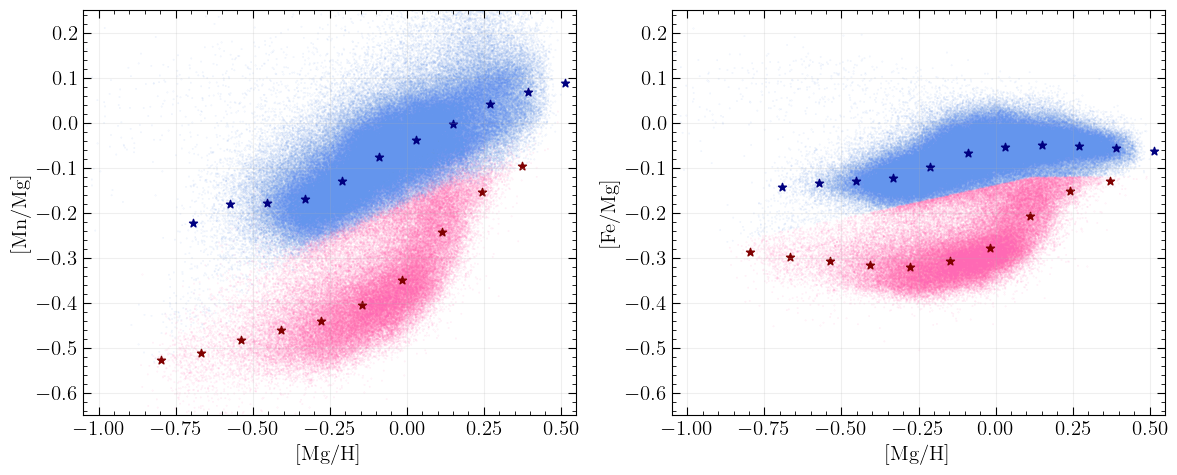

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

plt.scatter(data_all['MG_H'], data_all['MN_MG'], alpha = 0.2, color = data_all['color'], s = 0.05)

plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_all['MG_H'], data_all['FE_MG'], alpha = 0.2, color = data_all['color'], s = 0.05)


plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [96]:
less_than_75 = data_all[data_all['MG_H'] < 0.75]
len(less_than_75)

259409

# MG_H bins

In [97]:
mg_h_big_bin_edges = np.arange(-1.0, 1.0, 0.2) 
data_all['MG_H_big_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)
colors_big_bins = ['brown', 'black', 'blue', 'green', 'hotpink', 'purple', 'red', 'turquoise', 'gray']

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df

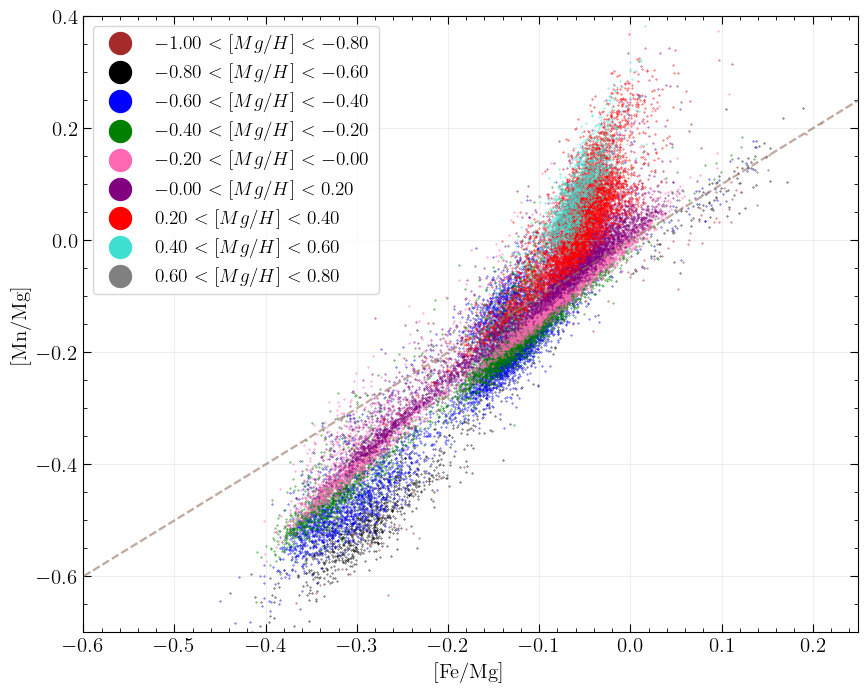

In [98]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]
xs = np.linspace(-1, 1, 100)

for i in range(len(mg_h_big_bin_edges) - 1):
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
    plt.plot(xs, xs, alpha = 0.1, linestyle='--')
    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Fe/Mg]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-0.60,0.25)
    plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=50)

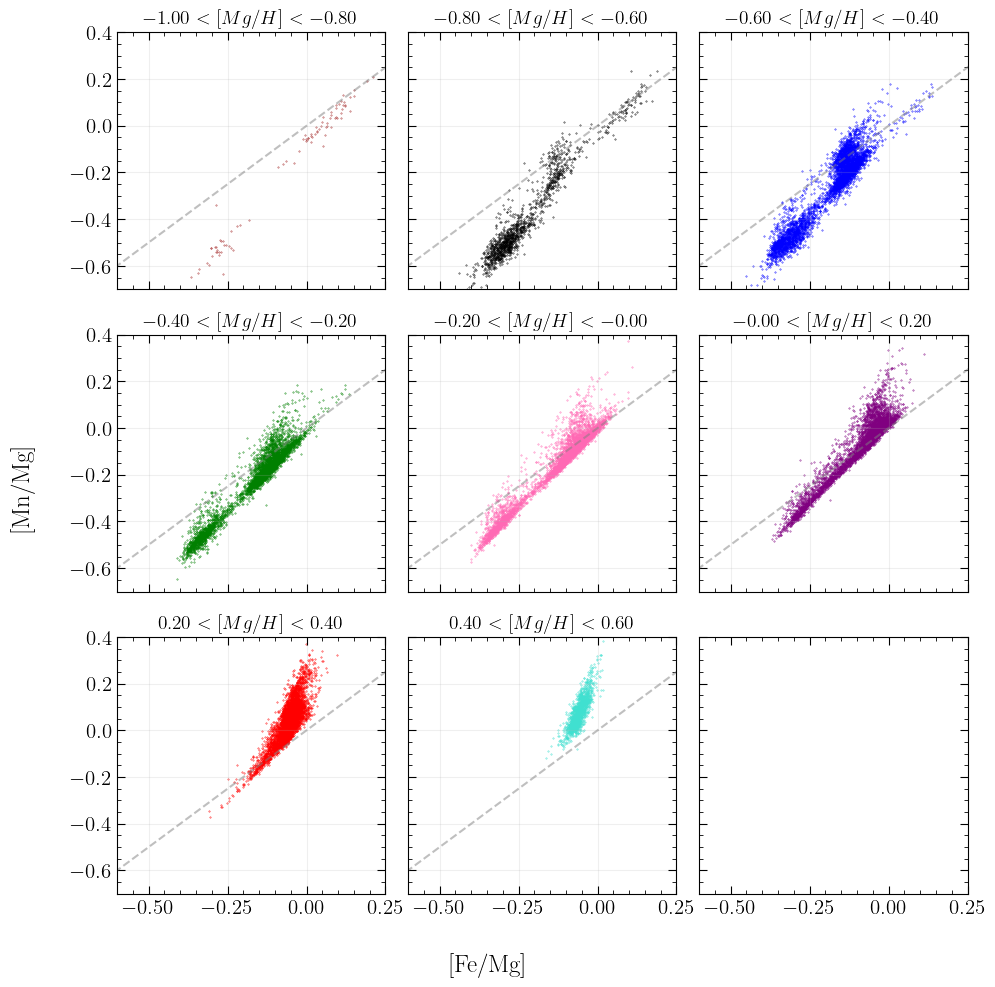

In [99]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)

    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'],
               s=0.1, color=colors_big_bins[i])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
plt.tight_layout()


plt.savefig("fish_head.png", dpi=300)

plt.show()


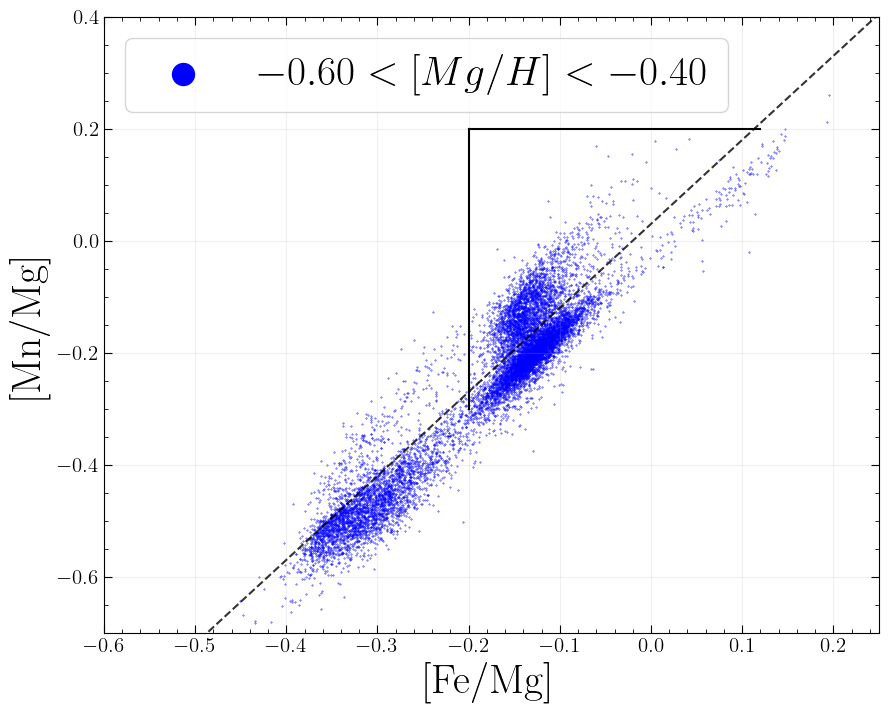

In [100]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]
xs = np.linspace(-1, 1, 100)

i = 2
df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
#df_to_plot = downsample(df_to_plot, 5000)
plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
#plt.plot(xs, xs, alpha = 0.8, linestyle='--', label = "y=x", color = 'gray')
plt.plot(xs, 1.5 * xs + 0.03, alpha = 0.8, linestyle='--', color = 'black')
plt.plot([-0.2, -0.2], [-0.3, 0.2], color = 'black')
plt.plot([-0.2, 0.12], [0.2, 0.2], color = 'black')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/Mg]', fontsize=30)
plt.ylabel('[Mn/Mg]', fontsize=30)
plt.xlim(-0.60,0.25)
plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=50, fontsize=30)

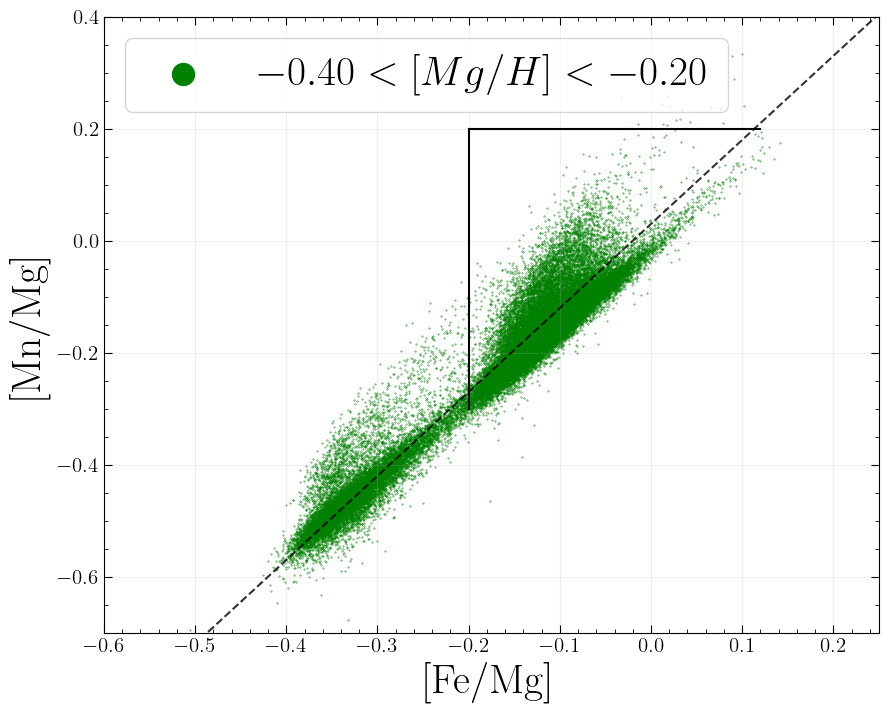

In [101]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]
xs = np.linspace(-1, 1, 100)

i = 3
df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
#df_to_plot = downsample(df_to_plot, 5000)
plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
#plt.plot(xs, xs, alpha = 0.8, linestyle='--', label = "y=x", color = 'gray')
plt.plot(xs, 1.5 * xs + 0.03, alpha = 0.8, linestyle='--', color = 'black')
plt.plot([-0.2, -0.2], [-0.3, 0.2], color = 'black')
plt.plot([-0.2, 0.12], [0.2, 0.2], color = 'black')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/Mg]', fontsize=30)
plt.ylabel('[Mn/Mg]', fontsize=30)
plt.xlim(-0.60,0.25)
plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=50, fontsize=30)

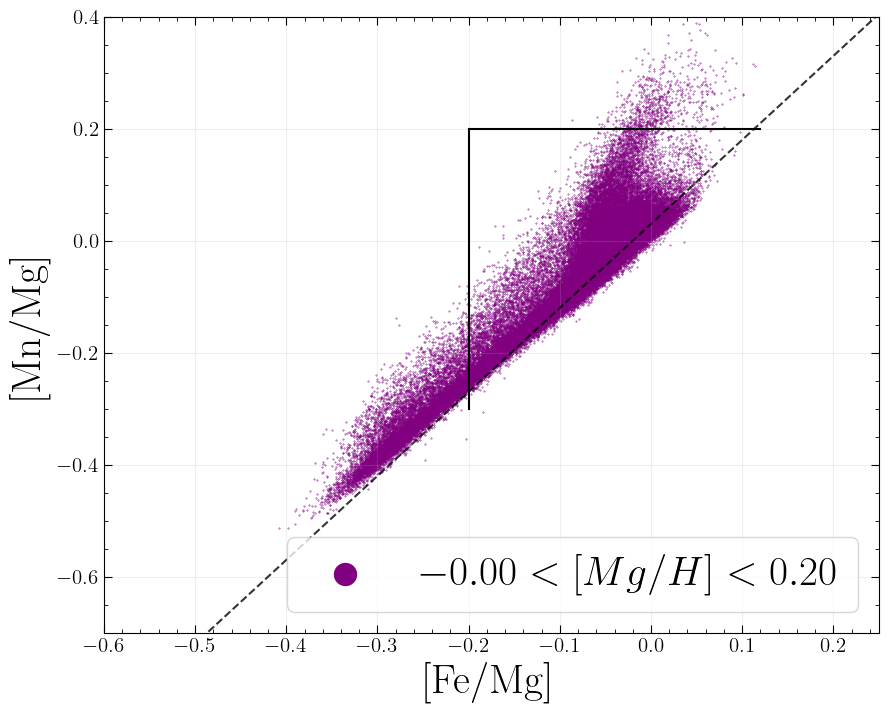

In [114]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]
xs = np.linspace(-1, 1, 100)

i = 5
df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
#df_to_plot = downsample(df_to_plot, 5000)
plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
#plt.plot(xs, xs, alpha = 0.8, linestyle='--', label = "y=x", color = 'gray')
plt.plot(xs, 1.5 * xs + 0.03, alpha = 0.8, linestyle='--', color = 'black')
plt.plot([-0.2, -0.2], [-0.3, 0.2], color = 'black')
plt.plot([-0.2, 0.12], [0.2, 0.2], color = 'black')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/Mg]', fontsize=30)
plt.ylabel('[Mn/Mg]', fontsize=30)
plt.xlim(-0.60,0.25)
plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=50, fontsize=30)

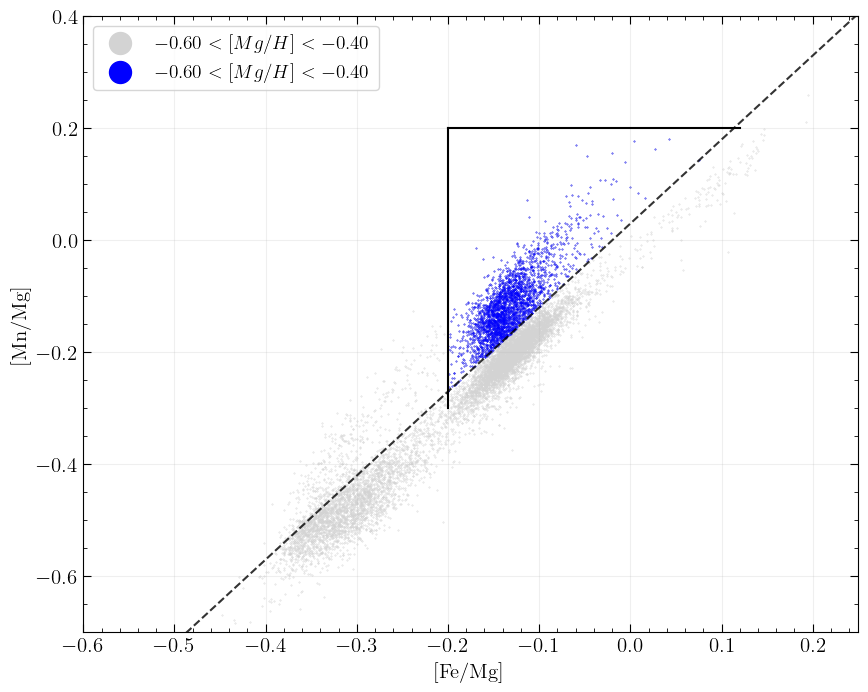

In [102]:
x_left  = -0.2
x_right =  0.12
y_line = 1.5 * data_all['FE_MG'] + 0.03
y_top = 0.2

fish_head_mask = (
    (data_all['FE_MG'] > x_left) &
    (data_all['FE_MG'] < x_right) &
    (data_all['MN_MG'] > y_line) &
    (data_all['MN_MG'] < y_top)
)
data_boxed = data_all[fish_head_mask]

plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]
xs = np.linspace(-1, 1, 100)

i = 2

df_to_plot_1 = data_all[data_all['MG_H_big_bin'] == i]
#df_to_plot = downsample(df_to_plot, 5000)
df_to_plot_2 = data_boxed[data_boxed['MG_H_big_bin'] == i]
plt.scatter(df_to_plot_1['FE_MG'], df_to_plot_1['MN_MG'], s = 0.1, color = 'lightgray', label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.scatter(df_to_plot_2['FE_MG'], df_to_plot_2['MN_MG'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
#plt.plot(xs, xs, alpha = 0.8, linestyle='--', label = "y=x", color = 'gray')
plt.plot(xs, 1.5 * xs + 0.03, alpha = 0.8, linestyle='--', color = 'black')
plt.plot([-0.2, -0.2], [-0.3, 0.2], color = 'black')
plt.plot([-0.2, 0.12], [0.2, 0.2], color = 'black')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/Mg]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-0.60,0.25)
plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=50)

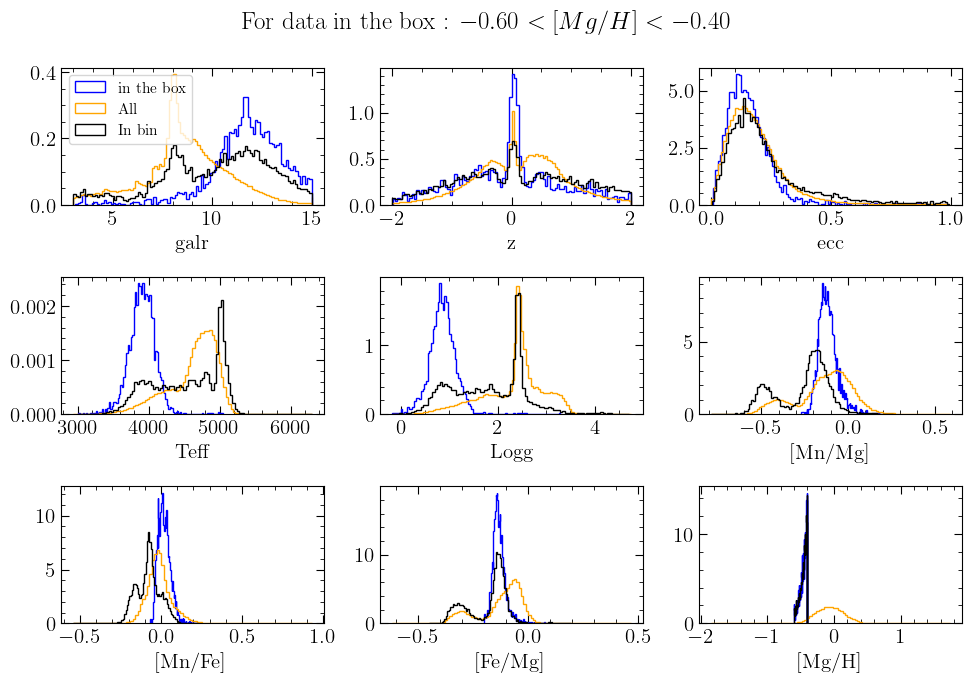

In [103]:
plt.figure(figsize=(10,7))
i = 2
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

n_bins = 100

plt.subplot(3,3,1)
plt.hist(data_boxed_toplot['galr'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['galr'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['galr'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('galr')
plt.legend(fontsize=11)

plt.subplot(3,3,2)
plt.hist(data_boxed_toplot['galz'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['galz'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['galz'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('z')

plt.subplot(3,3,3)
plt.hist(data_boxed_toplot['e'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['e'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['e'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('ecc')


plt.subplot(3,3,4)
plt.hist(data_boxed_toplot['TEFF'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['TEFF'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['TEFF'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('Teff')


plt.subplot(3,3,5)
plt.hist(data_boxed_toplot['LOGG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['LOGG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['LOGG'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('Logg')

plt.subplot(3,3,6)
plt.hist(data_boxed_toplot['MN_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['MN_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MN_MG'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Mn/Mg]')

plt.subplot(3,3,7)
plt.hist(data_boxed_toplot['MN_FE'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['MN_FE'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MN_FE'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Mn/Fe]')

plt.subplot(3,3,8)
plt.hist(data_boxed_toplot['FE_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['FE_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['FE_MG'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Fe/Mg]')

plt.subplot(3,3,9)
plt.hist(data_boxed_toplot['MG_H'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'blue')
plt.hist(data_all['MG_H'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MG_H'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Mg/H]')

plt.suptitle(rf'For data in the box : ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.tight_layout()

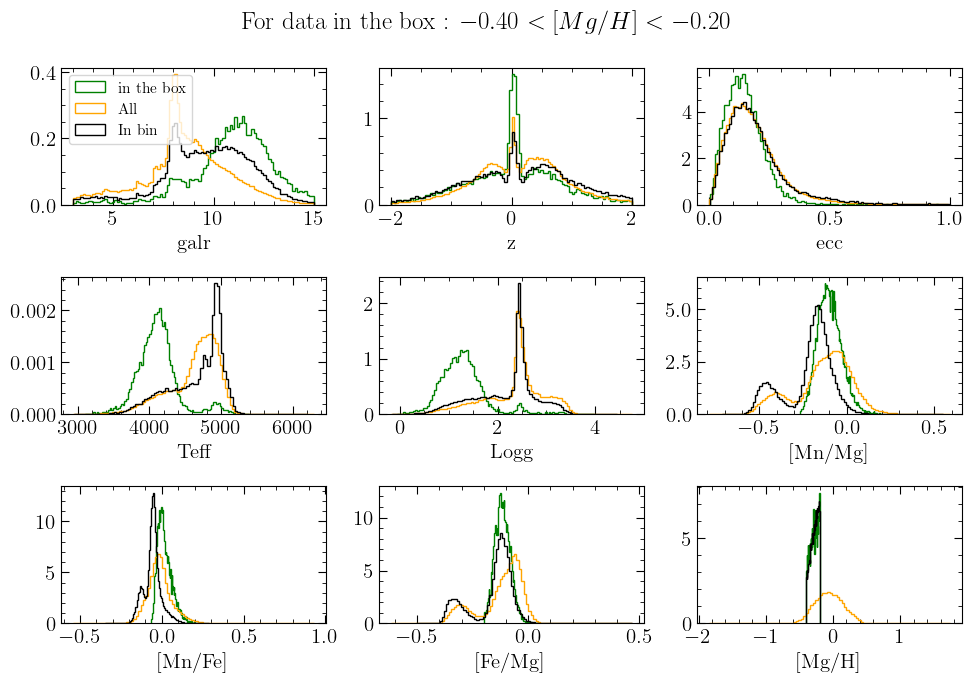

In [104]:
plt.figure(figsize=(10,7))
i = 3
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

n_bins = 100

plt.subplot(3,3,1)
plt.hist(data_boxed_toplot['galr'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['galr'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['galr'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('galr')
plt.legend(fontsize=11)

plt.subplot(3,3,2)
plt.hist(data_boxed_toplot['galz'], bins = n_bins, density=True, label = 'in the box', color = 'green', histtype='step')
plt.hist(data_all['galz'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['galz'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('z')

plt.subplot(3,3,3)
plt.hist(data_boxed_toplot['e'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['e'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['e'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('ecc')


plt.subplot(3,3,4)
plt.hist(data_boxed_toplot['TEFF'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['TEFF'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['TEFF'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('Teff')


plt.subplot(3,3,5)
plt.hist(data_boxed_toplot['LOGG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['LOGG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['LOGG'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('Logg')

plt.subplot(3,3,6)
plt.hist(data_boxed_toplot['MN_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['MN_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MN_MG'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Mn/Mg]')

plt.subplot(3,3,7)
plt.hist(data_boxed_toplot['MN_FE'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['MN_FE'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MN_FE'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Mn/Fe]')

plt.subplot(3,3,8)
plt.hist(data_boxed_toplot['FE_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['FE_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['FE_MG'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Fe/Mg]')

plt.subplot(3,3,9)
plt.hist(data_boxed_toplot['MG_H'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = 'green', )
plt.hist(data_all['MG_H'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MG_H'], bins = n_bins, alpha = 1, density=True, label = 'In bin', histtype='step', color = 'black')
plt.xlabel('[Mg/H]')

plt.suptitle(rf'For data in the box : ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.tight_layout()

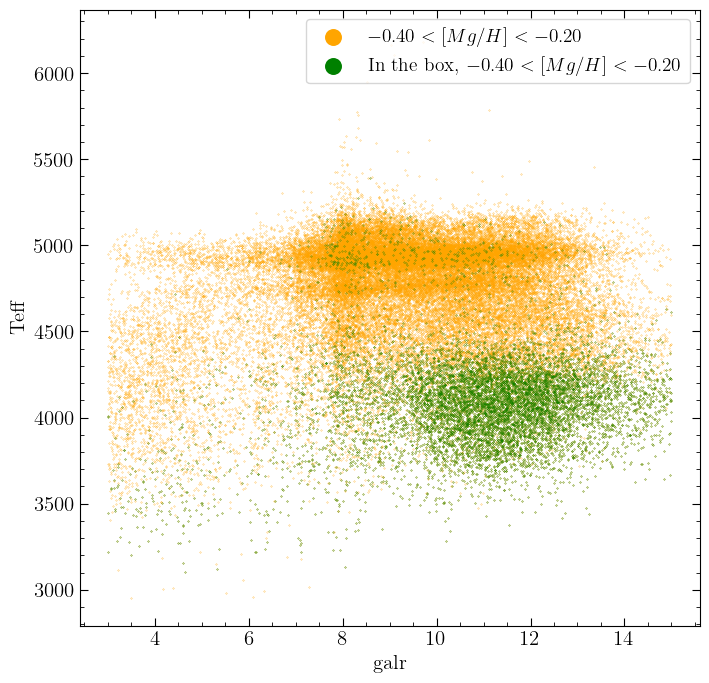

In [105]:
plt.figure(figsize=(8,8))
i = 3
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

plt.scatter(data_all_in_bin['galr'], data_all_in_bin['TEFF'], s = 0.05, color = 'orange', alpha = 1,
            label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.scatter(data_boxed_toplot['galr'], data_boxed_toplot['TEFF'], s = 0.05, color = 'green', zorder=5,
           label = rf'In the box, ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')

plt.legend(markerscale=50, loc = 'upper right')
plt.xlabel('galr')
plt.ylabel('Teff')
plt.savefig("plots/galr_teff_green.png", dpi=300)

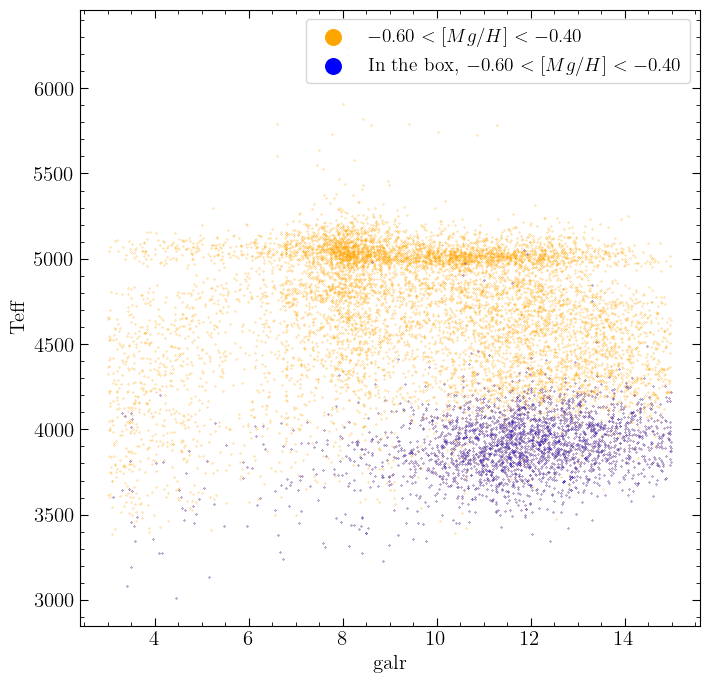

In [106]:
plt.figure(figsize=(8,8))
i = 2
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

#plt.scatter(data_all['galr'], data_all['TEFF'], s = 0.05, color = 'yellow', alpha = 0.2, label = 'All')
plt.scatter(data_all_in_bin['galr'], data_all_in_bin['TEFF'], s = 0.05, color = 'orange', alpha = 1,
            label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.scatter(data_boxed_toplot['galr'], data_boxed_toplot['TEFF'], s = 0.05, color = 'blue', zorder=5,
            label = rf'In the box, ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')

plt.legend(markerscale=50, loc = 'upper right')
plt.xlabel('galr')
plt.ylabel('Teff')

plt.savefig("plots/galr_teff_blue.png", dpi=300)

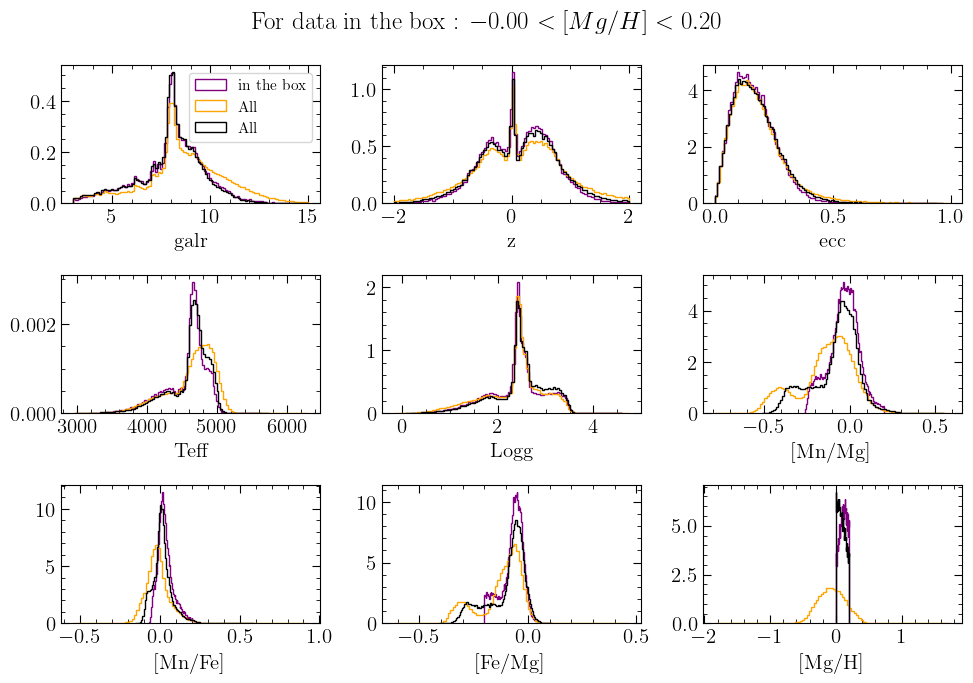

In [115]:
plt.figure(figsize=(10,7))
i = 5
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

n_bins = 100

plt.subplot(3,3,1)
plt.hist(data_boxed_toplot['galr'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['galr'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['galr'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('galr')
plt.legend(fontsize=11)

plt.subplot(3,3,2)
plt.hist(data_boxed_toplot['galz'], bins = n_bins, density=True, label = 'in the box', color = colors_big_bins[i], histtype='step')
plt.hist(data_all['galz'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['galz'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('z')

plt.subplot(3,3,3)
plt.hist(data_boxed_toplot['e'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['e'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['e'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('ecc')


plt.subplot(3,3,4)
plt.hist(data_boxed_toplot['TEFF'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['TEFF'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['TEFF'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('Teff')


plt.subplot(3,3,5)
plt.hist(data_boxed_toplot['LOGG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['LOGG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['LOGG'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('Logg')

plt.subplot(3,3,6)
plt.hist(data_boxed_toplot['MN_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['MN_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MN_MG'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('[Mn/Mg]')

plt.subplot(3,3,7)
plt.hist(data_boxed_toplot['MN_FE'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['MN_FE'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MN_FE'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('[Mn/Fe]')

plt.subplot(3,3,8)
plt.hist(data_boxed_toplot['FE_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['FE_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['FE_MG'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('[Fe/Mg]')

plt.subplot(3,3,9)
plt.hist(data_boxed_toplot['MG_H'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['MG_H'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.hist(data_all_in_bin['MG_H'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'black')
plt.xlabel('[Mg/H]')

plt.suptitle(rf'For data in the box : ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.tight_layout()

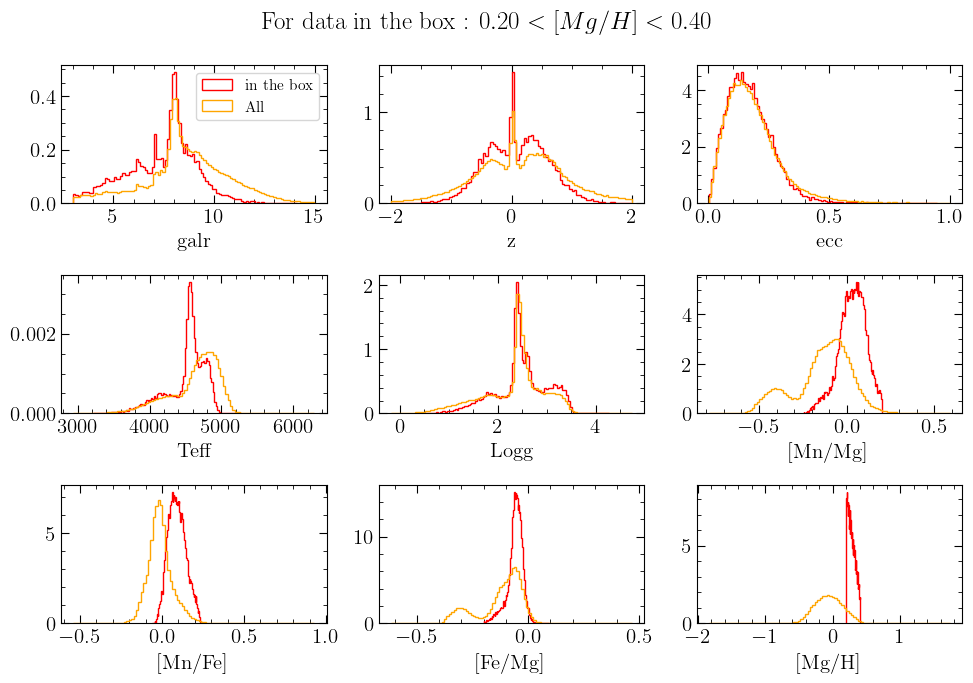

In [ ]:
plt.figure(figsize=(10,7))
i = 6
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

n_bins = 100

plt.subplot(3,3,1)
plt.hist(data_boxed_toplot['galr'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['galr'], bins = n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('galr')
plt.legend(fontsize=11)

plt.subplot(3,3,2)
plt.hist(data_boxed_toplot['galz'], bins = n_bins, density=True, label = 'in the box', color = colors_big_bins[i], histtype='step')
plt.hist(data_all['galz'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('z')

plt.subplot(3,3,3)
plt.hist(data_boxed_toplot['e'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['e'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('ecc')


plt.subplot(3,3,4)
plt.hist(data_boxed_toplot['TEFF'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['TEFF'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('Teff')


plt.subplot(3,3,5)
plt.hist(data_boxed_toplot['LOGG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['LOGG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('Logg')

plt.subplot(3,3,6)
plt.hist(data_boxed_toplot['MN_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['MN_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('[Mn/Mg]')

plt.subplot(3,3,7)
plt.hist(data_boxed_toplot['MN_FE'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['MN_FE'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('[Mn/Fe]')

plt.subplot(3,3,8)
plt.hist(data_boxed_toplot['FE_MG'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['FE_MG'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('[Fe/Mg]')

plt.subplot(3,3,9)
plt.hist(data_boxed_toplot['MG_H'], bins = n_bins, density=True, label = 'in the box', histtype='step', color = colors_big_bins[i])
plt.hist(data_all['MG_H'], bins=n_bins, alpha = 1, density=True, label = 'All', histtype='step', color = 'orange')
plt.xlabel('[Mg/H]')

plt.suptitle(rf'For data in the box : ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.tight_layout()

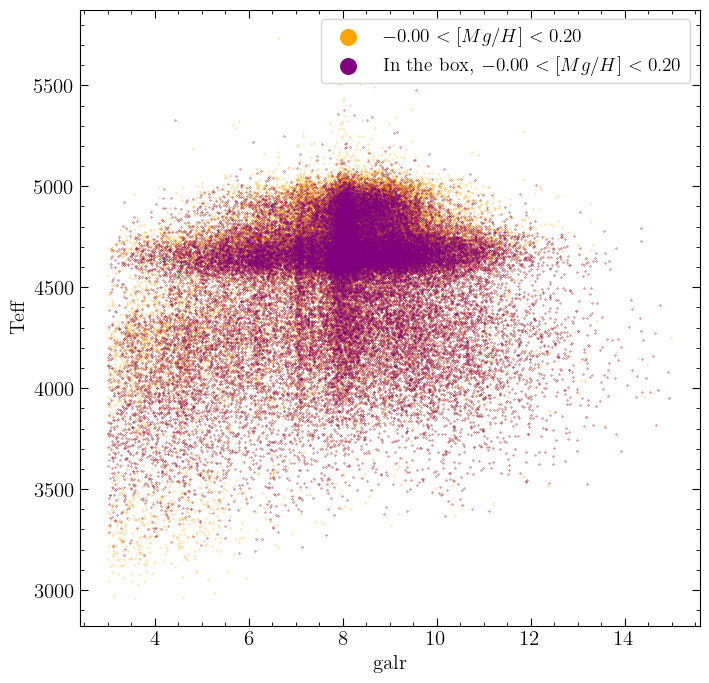

In [116]:
plt.figure(figsize=(8,8))
i = 5
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

plt.scatter(data_all_in_bin['galr'], data_all_in_bin['TEFF'], s = 0.05, color = 'orange', alpha = 1, label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.scatter(data_boxed_toplot['galr'], data_boxed_toplot['TEFF'], s = 0.05, color = colors_big_bins[i], zorder=5, label = rf'In the box, ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')

plt.legend(markerscale=50, loc = 'upper right')
plt.xlabel('galr')
plt.ylabel('Teff')

plt.savefig("plots/galr_teff_blue.png", dpi=300)

Text(0, 0.5, 'Teff')

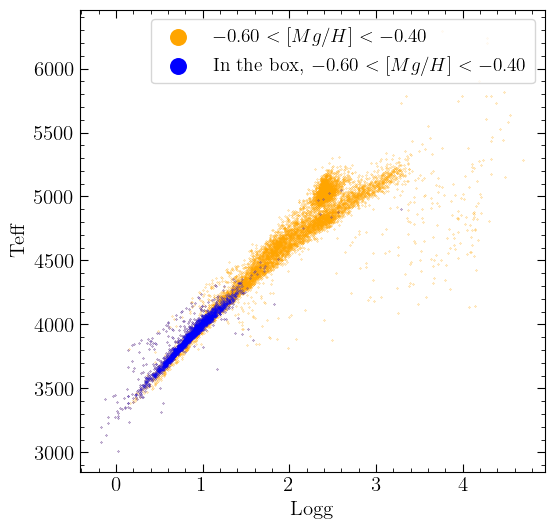

In [110]:
plt.figure(figsize=(6,6))
i = 2
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

#plt.scatter(data_all['galr'], data_all['TEFF'], s = 0.05, color = 'yellow', alpha = 0.2, label = 'All')
plt.scatter(data_all_in_bin['LOGG'], data_all_in_bin['TEFF'], s = 0.05, color = 'orange', alpha = 1,
            label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.scatter(data_boxed_toplot['LOGG'], data_boxed_toplot['TEFF'], s = 0.05, color = colors_big_bins[i], zorder=5,
            label = rf'In the box, ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')

plt.legend(markerscale=50, loc = 'upper right')
plt.xlabel('Logg')
plt.ylabel('Teff')

Text(0, 0.5, 'Teff')

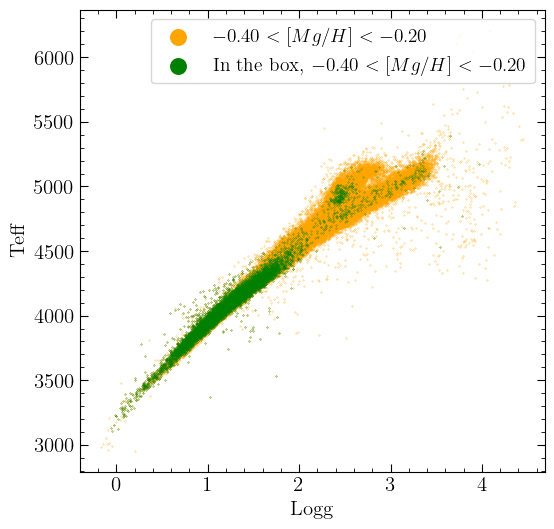

In [111]:
plt.figure(figsize=(6,6))
i = 3
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

#plt.scatter(data_all['galr'], data_all['TEFF'], s = 0.05, color = 'yellow', alpha = 0.2, label = 'All')
plt.scatter(data_all_in_bin['LOGG'], data_all_in_bin['TEFF'], s = 0.05, color = 'orange', alpha = 1,
            label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.scatter(data_boxed_toplot['LOGG'], data_boxed_toplot['TEFF'], s = 0.05, color = colors_big_bins[i], zorder=5,
            label = rf'In the box, ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')

plt.legend(markerscale=50, loc = 'upper right')
plt.xlabel('Logg')
plt.ylabel('Teff')

Text(0, 0.5, 'Teff')

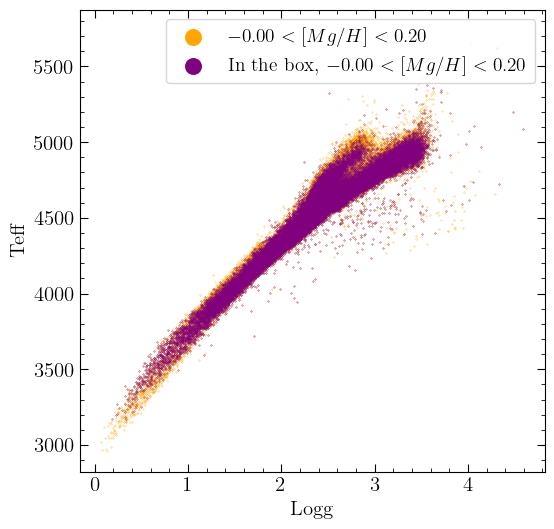

In [112]:
plt.figure(figsize=(6,6))
i = 5
data_boxed_toplot = data_boxed[data_boxed['MG_H_big_bin'] == i]
data_all_in_bin = data_all[data_all['MG_H_big_bin'] == i]

#plt.scatter(data_all['galr'], data_all['TEFF'], s = 0.05, color = 'yellow', alpha = 0.2, label = 'All')
plt.scatter(data_all_in_bin['LOGG'], data_all_in_bin['TEFF'], s = 0.05, color = 'orange', alpha = 1,
            label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
plt.scatter(data_boxed_toplot['LOGG'], data_boxed_toplot['TEFF'], s = 0.05, color = colors_big_bins[i], zorder=5,
            label = rf'In the box, ${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')

plt.legend(markerscale=50, loc = 'upper right')
plt.xlabel('Logg')
plt.ylabel('Teff')